# Bitcoin Directional Model Mk4

Identical starting point to Mk2 (same pipeline, same fixed top_n=15 feature selection, no de-dup, no validation split) — this is the notebook where further strategy development continues. Uses its own `data/mk4/` cache, separate from Mk2's `data/mk2/`, so both can be run independently without overwriting each other.

Pipeline:
1. Configure dependencies, paths, and credentials.
2. Pull 10 years of daily BTC OHLCV data.
3. Pull a broad CryptoQuant BTC feature catalog for the same date range.
4. Pull market data (equities, metals, energy, FX) via yfinance.
5. Pull economic data (CPI, rates, GDP, M2, unemployment) via the FRED API.
6. Build a candidate feature table for predicting whether BTC is bullish or bearish tomorrow.
7. Select a fixed, stability-filtered feature set on the training window only, fit a logistic regression, and evaluate on a strictly later holdout period.


## 1. Optional Dependency Install

Run this only if the active notebook kernel is missing packages. It installs into the exact Python environment backing the notebook.

In [1]:
import sys
import subprocess

REQUIRED_PACKAGES = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "matplotlib",
    "requests",
    "yfinance",
    "ipykernel",
]

print(f"Installing into: {sys.executable}")
subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--upgrade",
    *REQUIRED_PACKAGES,
])

print("Dependencies installed. Restart the notebook kernel before continuing.")


Installing into: /Users/gavinhussey/Downloads/rcm/scrapyard_project/.venv/bin/python


Dependencies installed. Restart the notebook kernel before continuing.


## 2. Imports, Paths, and API Credentials

This cell centralizes imports, file paths, and API credential loading. Put your keys in a `.env` file at the project root (see `.env.example`) once:

```text
CRYPTOQUANT_API_KEY=your_actual_api_key
CRYPTOQUANT_BASE_URL=https://api.cryptoquant.com
FRED_API_KEY=your_actual_fred_api_key
```

`FRED_API_KEY` is a free key from https://fred.stlouisfed.org/docs/api/api_key.html, used for economic indicator pulls. yfinance (market data) needs no key. The `.env` file is ignored by git.


In [2]:
import os
import sys
import time
from datetime import datetime, timedelta, timezone
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

try:
    import scipy
    import sklearn
    print("scipy:", scipy.__version__)
    print("scikit-learn:", sklearn.__version__)
except ImportError:
    print("scipy/scikit-learn not imported yet. Run dependency install if needed.")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
MK2_DIR = PROJECT_ROOT
MK2_DATA_DIR = MK2_DIR / "data" / "mk4"
MK2_DATA_DIR.mkdir(parents=True, exist_ok=True)

ENV_PATH = MK2_DIR / ".env"
BTC_OHLC_CACHE = MK2_DATA_DIR / "btc_usd_daily_ohlc_10y_coinbase.csv"
CRYPTOQUANT_FEATURE_CACHE = MK2_DATA_DIR / "cryptoquant_onchain_features.csv"
CRYPTOQUANT_FAILURE_LOG = MK2_DATA_DIR / "cryptoquant_pull_failures.csv"
MARKET_DATA_CACHE = MK2_DATA_DIR / "market_data_yfinance.csv"
MARKET_DATA_FAILURE_LOG = MK2_DATA_DIR / "market_data_pull_failures.csv"
ECONOMIC_DATA_CACHE = MK2_DATA_DIR / "economic_data_fred.csv"
ECONOMIC_DATA_FAILURE_LOG = MK2_DATA_DIR / "economic_data_pull_failures.csv"


def load_env_file(path):
    """Load simple KEY=VALUE lines from a local .env file into os.environ."""
    if not path.exists():
        return
    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip().strip("'").strip('"'))


load_env_file(ENV_PATH)

CRYPTOQUANT_API_KEY = os.getenv("CRYPTOQUANT_API_KEY")
if not CRYPTOQUANT_API_KEY:
    CRYPTOQUANT_API_KEY = getpass("Enter CryptoQuant API key, or press Enter to skip live CryptoQuant pulls: ").strip()

CRYPTOQUANT_BASE_URL = os.getenv("CRYPTOQUANT_BASE_URL", "https://api.cryptoquant.com")

FRED_API_KEY = os.getenv("FRED_API_KEY")
if not FRED_API_KEY:
    FRED_API_KEY = getpass("Enter FRED API key, or press Enter to skip live economic data pulls: ").strip()

FRED_BASE_URL = os.getenv("FRED_BASE_URL", "https://api.stlouisfed.org/fred")

print("Python executable:", sys.executable)
print("Mk2 data directory:", MK2_DATA_DIR)
print("CryptoQuant key loaded:", bool(CRYPTOQUANT_API_KEY))
print("CryptoQuant base URL:", CRYPTOQUANT_BASE_URL)
print("FRED key loaded:", bool(FRED_API_KEY))


scipy: 1.18.0
scikit-learn: 1.9.0
Python executable: /Users/gavinhussey/Downloads/rcm/scrapyard_project/.venv/bin/python
Mk2 data directory: /Users/gavinhussey/Downloads/rcm/bitcoin_directional/BTC-Price-Direction-Mk2/data/mk4
CryptoQuant key loaded: True
CryptoQuant base URL: https://api.cryptoquant.com
FRED key loaded: True


## 3. CryptoQuant API Helpers

Reusable request, response-normalization, and cache helpers. Endpoint availability can vary by CryptoQuant plan, so pull failures are logged instead of stopping the notebook.

In [3]:
def cryptoquant_get(path, params=None, base_url=CRYPTOQUANT_BASE_URL):
    """Call a CryptoQuant endpoint using the active notebook API key."""
    if not CRYPTOQUANT_API_KEY:
        raise RuntimeError("Set CRYPTOQUANT_API_KEY in .env or enter it when prompted before live API calls.")

    url = f"{base_url.rstrip('/')}/{path.lstrip('/')}"
    headers = {"Authorization": f"Bearer {CRYPTOQUANT_API_KEY}"}
    response = requests.get(url, headers=headers, params=params, timeout=60)
    response.raise_for_status()
    return response.json()


def extract_cryptoquant_rows(payload):
    """Handle common CryptoQuant JSON shapes and return row-like data."""
    if isinstance(payload, list):
        return payload
    if not isinstance(payload, dict):
        return payload
    if isinstance(payload.get("result"), dict) and "data" in payload["result"]:
        return payload["result"]["data"]
    if "data" in payload:
        return payload["data"]
    if "result" in payload:
        return payload["result"]
    return payload


def normalize_cryptoquant_metric(payload, output_col):
    rows = extract_cryptoquant_rows(payload)
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("CryptoQuant returned an empty payload")

    date_candidates = ["date", "datetime", "time", "timestamp", "start_time"]
    date_col = next((col for col in date_candidates if col in df.columns), None)
    if date_col is None:
        raise KeyError(f"No date-like column found. Columns: {list(df.columns)}")

    value_candidates = ["value", "close", "reserve", "flow_total", "total", "mean"]
    value_col = next((col for col in value_candidates if col in df.columns), None)
    if value_col is None:
        numeric_cols = [col for col in df.columns if col != date_col and pd.api.types.is_numeric_dtype(df[col])]
        if not numeric_cols:
            raise KeyError(f"No value-like numeric column found. Columns: {list(df.columns)}")
        value_col = numeric_cols[0]

    df["Date"] = pd.to_datetime(df[date_col], utc=True, errors="coerce").dt.date
    df[output_col] = pd.to_numeric(df[value_col], errors="coerce")
    return (
        df[["Date", output_col]]
        .dropna(subset=["Date"])
        .drop_duplicates(subset=["Date"], keep="last")
        .sort_values("Date")
        .reset_index(drop=True)
    )


## 4. Pull 10 Years of Daily BTC OHLCV

Fetches daily BTC-USD candles from Coinbase, caches the data locally, and defines the date range used for all external features.

In [4]:
def fetch_coinbase_daily_ohlc(product_id="BTC-USD", years=10, refresh=False):
    if BTC_OHLC_CACHE.exists() and not refresh:
        return pd.read_csv(BTC_OHLC_CACHE, parse_dates=["Date"])

    end = datetime.now(timezone.utc)
    start = end - timedelta(days=365 * years + 3)
    chunk_days = 300  # Coinbase limits candle responses to 300 buckets.
    rows = []
    cursor = start

    while cursor < end:
        chunk_end = min(cursor + timedelta(days=chunk_days), end)
        params = {
            "start": cursor.isoformat(),
            "end": chunk_end.isoformat(),
            "granularity": 86400,
        }
        url = f"https://api.exchange.coinbase.com/products/{product_id}/candles"
        response = requests.get(url, params=params, timeout=60)
        response.raise_for_status()
        rows.extend(response.json())
        cursor = chunk_end
        time.sleep(0.2)

    ohlc = pd.DataFrame(rows, columns=["time", "Low", "High", "Open", "Close", "Volume"])
    ohlc["Date"] = pd.to_datetime(ohlc["time"], unit="s", utc=True).dt.tz_localize(None)
    ohlc = (
        ohlc.drop(columns=["time"])
        .drop_duplicates(subset=["Date"])
        .sort_values("Date")
        .reset_index(drop=True)
    )
    ohlc = ohlc[["Date", "Open", "High", "Low", "Close", "Volume"]]
    ohlc.to_csv(BTC_OHLC_CACHE, index=False)
    return ohlc


btc_ohlc = fetch_coinbase_daily_ohlc(refresh=False)
btc_ohlc["Date"] = pd.to_datetime(btc_ohlc["Date"])
BTC_START_DATE = btc_ohlc["Date"].min().date()
BTC_END_DATE = btc_ohlc["Date"].max().date()

print(btc_ohlc.shape)
print(BTC_START_DATE, "to", BTC_END_DATE)
btc_ohlc.head()


(3653, 6)
2016-07-06 to 2026-07-06


,Date,Open,High,Low,Close,Volume
0,2016-07-06,669.75,680.79,665.00,678.79,5668.238078
1,2016-07-07,678.79,683.44,611.94,641.97,12281.480613
2,2016-07-08,641.97,667.33,638.04,667.33,11055.365742
3,2016-07-09,667.07,667.30,608.00,657.61,9607.695915
4,2016-07-10,657.60,657.61,641.00,652.44,3705.894148


## 5. Plot BTC OHLCV

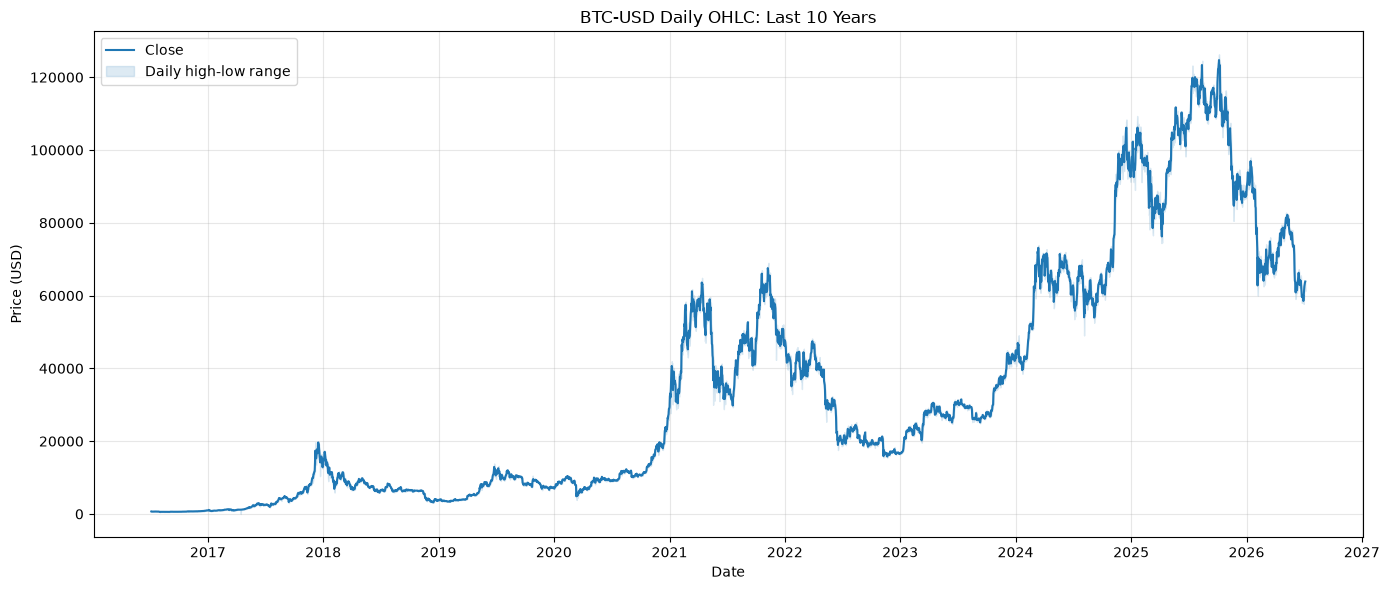

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(btc_ohlc["Date"], btc_ohlc["Close"], label="Close", linewidth=1.5, color="#1f77b4")
ax.fill_between(
    btc_ohlc["Date"],
    btc_ohlc["Low"],
    btc_ohlc["High"],
    color="#1f77b4",
    alpha=0.15,
    label="Daily high-low range",
)

ax.set_title("BTC-USD Daily OHLC: Last 10 Years")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 6. Pull CryptoQuant BTC Feature Catalog

Pulls a broad BTC feature catalog for the same date range as the Coinbase OHLCV data. Successful metrics are merged into `cryptoquant_onchain_features.csv`; unavailable endpoints are logged in `cryptoquant_pull_failures.csv`.

**Known limitation:** this API key's plan only returns the trailing ~100 days of history for any endpoint, regardless of the requested `from` date (verified directly against the live API). That's far short of the 10-year window this backtest needs, so on-chain features are pulled here for visibility but are deliberately **excluded from the modeling table in Section 9** rather than silently backfilled with mostly-missing data. Revisit if the plan is upgraded to include full history.


In [6]:
COMMON_CQ_PARAMS = {
    "window": "day",
    "from": str(BTC_START_DATE),
    "to": str(BTC_END_DATE),
}

CRYPTOQUANT_FEATURE_CATALOG = [
    {"name": "Exchange Reserve", "path": "/v1/btc/exchange-flows/reserve", "params": {"exchange": "all_exchange"}},
    {"name": "Exchange Inflow", "path": "/v1/btc/exchange-flows/inflow", "params": {"exchange": "all_exchange"}},
    {"name": "Exchange Outflow", "path": "/v1/btc/exchange-flows/outflow", "params": {"exchange": "all_exchange"}},
    {"name": "Exchange Netflow", "path": "/v1/btc/exchange-flows/netflow", "params": {"exchange": "all_exchange"}},
    {"name": "Exchange Transactions Count Inflow", "path": "/v1/btc/exchange-flows/transactions-count-inflow", "params": {"exchange": "all_exchange"}},
    {"name": "Exchange Transactions Count Outflow", "path": "/v1/btc/exchange-flows/transactions-count-outflow", "params": {"exchange": "all_exchange"}},
    {"name": "Miner Reserve", "path": "/v1/btc/miner-flows/reserve", "params": {"miner": "all_miner"}},
    {"name": "Miner Inflow", "path": "/v1/btc/miner-flows/inflow", "params": {"miner": "all_miner"}},
    {"name": "Miner Outflow", "path": "/v1/btc/miner-flows/outflow", "params": {"miner": "all_miner"}},
    {"name": "Miner Netflow", "path": "/v1/btc/miner-flows/netflow", "params": {"miner": "all_miner"}},
    {"name": "Hashrate", "path": "/v1/btc/network-data/hashrate", "params": {}},
    {"name": "Difficulty", "path": "/v1/btc/network-data/difficulty", "params": {}},
    {"name": "Active Addresses", "path": "/v1/btc/network-data/active-addresses", "params": {}},
    {"name": "New Addresses", "path": "/v1/btc/network-data/new-addresses", "params": {}},
    {"name": "Transaction Count", "path": "/v1/btc/network-data/transactions-count", "params": {}},
    {"name": "Tokens Transferred", "path": "/v1/btc/network-data/tokens-transferred", "params": {}},
    {"name": "Fees Total", "path": "/v1/btc/network-data/fees", "params": {}},
    {"name": "MVRV Ratio", "path": "/v1/btc/flow-indicator/mvrv", "params": {}},
    {"name": "SOPR", "path": "/v1/btc/flow-indicator/sopr", "params": {}},
    {"name": "Puell Multiple", "path": "/v1/btc/flow-indicator/puell-multiple", "params": {}},
    {"name": "NUPL", "path": "/v1/btc/flow-indicator/nupl", "params": {}},
    {"name": "Mean Coin Age", "path": "/v1/btc/flow-indicator/mean-coin-age", "params": {}},
    {"name": "Open Interest", "path": "/v1/btc/market-data/open-interest", "params": {"exchange": "all_exchange", "symbol": "all_symbol"}},
    {"name": "Funding Rates", "path": "/v1/btc/market-data/funding-rates", "params": {"exchange": "all_exchange", "symbol": "all_symbol"}},
    {"name": "Taker Buy Sell Ratio", "path": "/v1/btc/market-data/taker-buy-sell-ratio", "params": {"exchange": "all_exchange", "symbol": "all_symbol"}},
    {"name": "Estimated Leverage Ratio", "path": "/v1/btc/market-data/estimated-leverage-ratio", "params": {"exchange": "all_exchange"}},
    {"name": "Long Liquidations", "path": "/v1/btc/market-data/liquidations-long", "params": {"exchange": "all_exchange", "symbol": "all_symbol"}},
    {"name": "Short Liquidations", "path": "/v1/btc/market-data/liquidations-short", "params": {"exchange": "all_exchange", "symbol": "all_symbol"}},
]

print(f"Configured CryptoQuant feature candidates: {len(CRYPTOQUANT_FEATURE_CATALOG)}")


Configured CryptoQuant feature candidates: 28


In [7]:
def pull_cryptoquant_feature_catalog(refresh=False, pause_seconds=0.25):
    if CRYPTOQUANT_FEATURE_CACHE.exists() and CRYPTOQUANT_FAILURE_LOG.exists() and not refresh:
        print("Loading cached CryptoQuant features. Set refresh=True to pull again.")
        features = pd.read_csv(CRYPTOQUANT_FEATURE_CACHE, parse_dates=["Date"])
        failures = pd.read_csv(CRYPTOQUANT_FAILURE_LOG) if CRYPTOQUANT_FAILURE_LOG.stat().st_size > 0 else pd.DataFrame(columns=["name", "path", "error"])
        return features, failures

    merged = None
    failures = []

    for item in CRYPTOQUANT_FEATURE_CATALOG:
        name = item["name"]
        params = {**COMMON_CQ_PARAMS, **item.get("params", {})}
        try:
            payload = cryptoquant_get(item["path"], params=params)
            metric_df = normalize_cryptoquant_metric(payload, output_col=name)
            metric_df = metric_df[(metric_df["Date"] >= BTC_START_DATE) & (metric_df["Date"] <= BTC_END_DATE)]
            if metric_df.empty:
                raise ValueError("No rows inside BTC OHLC date range")
            merged = metric_df if merged is None else pd.merge(merged, metric_df, on="Date", how="outer")
            print(f"Pulled {name}: {len(metric_df):,} rows")
        except Exception as exc:
            failures.append({"name": name, "path": item["path"], "error": repr(exc)})
            print(f"Skipped {name}: {exc}")
        time.sleep(pause_seconds)

    if merged is None:
        merged = pd.DataFrame({"Date": btc_ohlc["Date"].dt.date})
    merged = merged.sort_values("Date").reset_index(drop=True)
    failures_df = pd.DataFrame(failures, columns=["name", "path", "error"])

    merged.to_csv(CRYPTOQUANT_FEATURE_CACHE, index=False)
    failures_df.to_csv(CRYPTOQUANT_FAILURE_LOG, index=False)
    return merged, failures_df


cryptoquant_features, cryptoquant_failures = pull_cryptoquant_feature_catalog(refresh=False)
cryptoquant_features.head()


Loading cached CryptoQuant features. Set refresh=True to pull again.


,Date
0,2016-07-06
1,2016-07-07
2,2016-07-08
3,2016-07-09
4,2016-07-10


## 7. Pull Market Data (yfinance)

Pulls daily closes for cross-asset market series (equities, metals, energy, FX) over the same date range as the BTC OHLCV data, using yfinance. This is an external source independent of CryptoQuant. Successful tickers are merged into `market_data_yfinance.csv`; failed pulls are logged in `market_data_pull_failures.csv`.


In [8]:
MARKET_TICKER_CATALOG = [
    {"name": "SP500", "ticker": "^GSPC"},
    {"name": "Nasdaq", "ticker": "^IXIC"},
    {"name": "Dow", "ticker": "^DJI"},
    {"name": "Gold", "ticker": "GC=F"},
    {"name": "Silver", "ticker": "SI=F"},
    {"name": "Copper", "ticker": "HG=F"},
    {"name": "Oil", "ticker": "CL=F"},
    {"name": "Natural Gas", "ticker": "NG=F"},
    {"name": "Dollar Index", "ticker": "DX-Y.NYB"},
    {"name": "EURUSD", "ticker": "EURUSD=X"},
    {"name": "USDCNY", "ticker": "USDCNY=X"},
]


def pull_market_data_yfinance(refresh=False, pause_seconds=0.25):
    if MARKET_DATA_CACHE.exists() and MARKET_DATA_FAILURE_LOG.exists() and not refresh:
        print("Loading cached market data. Set refresh=True to pull again.")
        market_features = pd.read_csv(MARKET_DATA_CACHE, parse_dates=["Date"])
        market_failures = pd.read_csv(MARKET_DATA_FAILURE_LOG) if MARKET_DATA_FAILURE_LOG.stat().st_size > 0 else pd.DataFrame(columns=["name", "ticker", "error"])
        return market_features, market_failures

    import yfinance as yf

    merged = None
    failures = []

    for item in MARKET_TICKER_CATALOG:
        name, ticker = item["name"], item["ticker"]
        try:
            history = yf.download(
                ticker,
                start=str(BTC_START_DATE),
                end=str(BTC_END_DATE + timedelta(days=1)),
                progress=False,
                auto_adjust=True,
            )
            if history.empty:
                raise ValueError("yfinance returned no rows")
            if isinstance(history.columns, pd.MultiIndex):
                history.columns = history.columns.get_level_values(0)
            metric_df = history[["Close"]].rename(columns={"Close": name}).reset_index()
            metric_df["Date"] = pd.to_datetime(metric_df["Date"]).dt.date
            metric_df = metric_df[["Date", name]].dropna().sort_values("Date")
            merged = metric_df if merged is None else pd.merge(merged, metric_df, on="Date", how="outer")
            print(f"Pulled {name} ({ticker}): {len(metric_df):,} rows")
        except Exception as exc:
            failures.append({"name": name, "ticker": ticker, "error": repr(exc)})
            print(f"Skipped {name} ({ticker}): {exc}")
        time.sleep(pause_seconds)

    if merged is None:
        merged = pd.DataFrame({"Date": []})
    merged = merged.sort_values("Date").reset_index(drop=True)
    failures_df = pd.DataFrame(failures, columns=["name", "ticker", "error"])

    merged.to_csv(MARKET_DATA_CACHE, index=False)
    failures_df.to_csv(MARKET_DATA_FAILURE_LOG, index=False)
    return merged, failures_df


market_features, market_failures = pull_market_data_yfinance(refresh=False)
market_features.head()


Loading cached market data. Set refresh=True to pull again.


,Date,SP500,Nasdaq,Dow,Gold,Silver,Copper,Oil,Natural Gas,Dollar Index,EURUSD,USDCNY
0,2016-07-06,2099.729980,4859.160156,17918.619141,1364.900024,20.160000,2.1515,47.430000,2.786,96.059998,1.106501,6.6697
1,2016-07-07,2097.899902,4876.810059,17895.880859,1360.099976,19.798000,2.1225,45.139999,2.777,96.330002,1.109903,6.6830
2,2016-07-08,2129.899902,4956.759766,18146.740234,1356.599976,20.058001,2.1185,45.410000,2.801,96.300003,1.106574,6.6711
3,2016-07-11,2137.159912,4988.640137,18226.929688,1355.000000,20.264000,2.1470,44.759998,2.702,96.570000,1.104399,6.6781
4,2016-07-12,2152.139893,5022.819824,18347.669922,1334.099976,20.129999,2.2110,46.799999,2.734,96.440002,1.105803,6.6839


## 8. Pull Economic Data (FRED)

Pulls macro/economic indicators from the St. Louis Fed's FRED API — another external source independent of CryptoQuant and yfinance. Each series is shifted forward by its typical publication lag (FRED dates observations by the *reference period*, not the release date — e.g. January CPI is dated `2024-01-01` in the API but isn't published until mid-February) and then forward-filled to daily frequency, so a given day only ever sees data that was actually public by that date. `10Y Treasury Yield` is a same-day market-observed series and needs only a 1-day lag; the rest are monthly/quarterly releases with real reporting delays. Successful series are merged into `economic_data_fred.csv`; failed pulls are logged in `economic_data_pull_failures.csv`.


In [9]:
FRED_SERIES_CATALOG = [
    # has_revisions=True series (CPI, Fed Funds, GDP, M2, Unemployment) are pulled
    # vintage-of-record: output_type=4 asks FRED/ALFRED for each observation's
    # *initial* release only, and the "realtime_start" FRED returns with it is the
    # actual calendar date that value first became public. We use that as the Date,
    # so the model only ever sees what was really known at the time -- no reliance
    # on a guessed publication_lag_days, and no leakage of later revisions.
    #
    # DGS10 (has_revisions=False) is a same-day market-observed daily series that
    # ALFRED doesn't track vintages for (output_type=4 errors: too many vintage
    # dates for a never-revised daily series). It keeps the simple pull with a
    # small fixed publication_lag_days as a safety margin.
    {"name": "CPI", "series_id": "CPIAUCSL", "has_revisions": True, "publication_lag_days": 45},
    {"name": "Fed Funds Rate", "series_id": "FEDFUNDS", "has_revisions": True, "publication_lag_days": 35},
    {"name": "10Y Treasury Yield", "series_id": "DGS10", "has_revisions": False, "publication_lag_days": 1},
    {"name": "GDP", "series_id": "GDPC1", "has_revisions": True, "publication_lag_days": 120},
    {"name": "M2 Money Supply", "series_id": "M2SL", "has_revisions": True, "publication_lag_days": 45},
    {"name": "Unemployment Rate", "series_id": "UNRATE", "has_revisions": True, "publication_lag_days": 40},
]

# ALFRED's shorthand for "no lower/upper bound" on a real-time period.
ALFRED_REALTIME_START = "1776-07-04"
ALFRED_REALTIME_END = "9999-12-31"


def fred_get(series_id, params=None, base_url=FRED_BASE_URL):
    if not FRED_API_KEY:
        raise RuntimeError("Set FRED_API_KEY in .env or enter it when prompted before live FRED pulls.")
    url = f"{base_url.rstrip('/')}/series/observations"
    request_params = {
        "series_id": series_id,
        "api_key": FRED_API_KEY,
        "file_type": "json",
        **(params or {}),
    }
    response = requests.get(url, params=request_params, timeout=60)
    response.raise_for_status()
    return response.json().get("observations", [])


def fetch_vintage_of_record(series_id, observation_start, observation_end):
    """Initial-release values with their true publish dates, via ALFRED output_type=4."""
    observations = fred_get(
        series_id,
        params={
            "observation_start": str(observation_start),
            "observation_end": str(observation_end),
            "output_type": 4,
            "realtime_start": ALFRED_REALTIME_START,
            "realtime_end": ALFRED_REALTIME_END,
        },
    )
    df = pd.DataFrame(observations)
    if df.empty:
        return df
    # realtime_start is the calendar date this vintage (the initial release) became
    # public -- that's what we merge on, not the reference-period "date" column.
    df = df[["realtime_start", "value"]].rename(columns={"realtime_start": "Date"})
    df["Date"] = pd.to_datetime(df["Date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df.dropna(subset=["value"]).sort_values("Date").reset_index(drop=True)


def fetch_same_day_series(series_id, observation_start, observation_end):
    """Plain pull for series with no meaningful revision history (e.g. DGS10)."""
    observations = fred_get(
        series_id,
        params={
            "observation_start": str(observation_start),
            "observation_end": str(observation_end),
        },
    )
    df = pd.DataFrame(observations)
    if df.empty:
        return df
    df = df[["date", "value"]].rename(columns={"date": "Date"})
    df["Date"] = pd.to_datetime(df["Date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df.dropna(subset=["value"]).sort_values("Date").reset_index(drop=True)


def pull_economic_data_fred(refresh=False, pause_seconds=0.25):
    if ECONOMIC_DATA_CACHE.exists() and ECONOMIC_DATA_FAILURE_LOG.exists() and not refresh:
        print("Loading cached economic data. Set refresh=True to pull again.")
        economic_features = pd.read_csv(ECONOMIC_DATA_CACHE, parse_dates=["Date"])
        economic_failures = pd.read_csv(ECONOMIC_DATA_FAILURE_LOG) if ECONOMIC_DATA_FAILURE_LOG.stat().st_size > 0 else pd.DataFrame(columns=["name", "series_id", "error"])
        return economic_features, economic_failures

    merged = None
    failures = []

    for item in FRED_SERIES_CATALOG:
        name, series_id = item["name"], item["series_id"]
        has_revisions = item.get("has_revisions", True)
        publication_lag_days = item.get("publication_lag_days", 0)
        try:
            if has_revisions:
                value_df = fetch_vintage_of_record(series_id, BTC_START_DATE, BTC_END_DATE)
                lag_note = "vintage-of-record (true publish date via ALFRED)"
            else:
                value_df = fetch_same_day_series(series_id, BTC_START_DATE, BTC_END_DATE)
                # Shift to the date it was actually published, not the reference period
                # it describes, so the merge can't leak a same-day print backward.
                value_df["Date"] = value_df["Date"] + pd.Timedelta(days=publication_lag_days)
                lag_note = f"{publication_lag_days}d publication lag"

            if value_df.empty:
                raise ValueError("FRED returned no usable observations")

            value_df = value_df.rename(columns={"value": name})

            # Forward-fill only: every day gets the most recent *already-published*
            # value and nothing newer. No interpolation, since linear interpolation
            # between two releases would require knowing the later (future) release.
            daily_index = pd.date_range(value_df["Date"].min(), BTC_END_DATE, freq="D")
            metric_daily = (
                value_df.set_index("Date")[[name]]
                .reindex(daily_index)
                .ffill()
                .rename_axis("Date")
                .reset_index()
            )
            metric_daily["Date"] = metric_daily["Date"].dt.date
            merged = metric_daily if merged is None else pd.merge(merged, metric_daily, on="Date", how="outer")
            print(f"Pulled {name} ({series_id}): {len(metric_daily):,} daily rows after {lag_note} + forward-fill")
        except Exception as exc:
            failures.append({"name": name, "series_id": series_id, "error": repr(exc)})
            print(f"Skipped {name} ({series_id}): {exc}")
        time.sleep(pause_seconds)

    if merged is None:
        merged = pd.DataFrame({"Date": []})
    merged = merged.sort_values("Date").reset_index(drop=True)
    failures_df = pd.DataFrame(failures, columns=["name", "series_id", "error"])

    merged.to_csv(ECONOMIC_DATA_CACHE, index=False)
    failures_df.to_csv(ECONOMIC_DATA_FAILURE_LOG, index=False)
    return merged, failures_df


economic_features, economic_failures = pull_economic_data_fred(refresh=False)
economic_features.head()


Loading cached economic data. Set refresh=True to pull again.


,Date,CPI,Fed Funds Rate,10Y Treasury Yield,GDP,M2 Money Supply,Unemployment Rate
0,2016-07-07,NaN,NaN,1.38,NaN,NaN,NaN
1,2016-07-08,NaN,NaN,1.40,NaN,NaN,NaN
2,2016-07-09,NaN,NaN,1.37,NaN,NaN,NaN
3,2016-07-10,NaN,NaN,1.37,NaN,NaN,NaN
4,2016-07-11,NaN,NaN,1.37,NaN,NaN,NaN


## 9. Build Raw Modeling Table

This section creates a raw daily table with BTC OHLCV plus any fresh CryptoQuant, market (yfinance), and economic (FRED) features that have been pulled. It does not select final features — feature selection is train-only and happens later in this notebook (Section 13).


In [10]:
RAW_MODEL_TABLE_CACHE = MK2_DATA_DIR / "raw_model_table.csv"


def load_optional_mk2_feature_csv(path):
    """Load an optional Mk2-owned feature file with a Date column."""
    path = Path(path)
    if not path.exists():
        return None
    df = pd.read_csv(path)
    if "Date" not in df.columns:
        raise ValueError(f"{path} must contain a Date column")
    df["Date"] = pd.to_datetime(df["Date"]).dt.date
    return df.sort_values("Date").reset_index(drop=True)


raw_model_table = btc_ohlc.copy()
raw_model_table["Date"] = pd.to_datetime(raw_model_table["Date"]).dt.date

# CryptoQuant is deliberately excluded here: this API key's plan only serves the
# trailing ~100 days of history for any endpoint (confirmed against the live API),
# which is far short of the 10-year window this backtest needs. Merging it in would
# leave the on-chain columns >97% NaN and forward-fill would carry a single ~100-day-old
# snapshot across nearly the entire backtest. cryptoquant_features/cryptoquant_failures
# are still pulled above for visibility; just not merged into the modeling table.
optional_feature_files = [MARKET_DATA_CACHE, ECONOMIC_DATA_CACHE]
loaded_optional_files = []
for feature_file in optional_feature_files:
    feature_df = load_optional_mk2_feature_csv(feature_file)
    if feature_df is None:
        continue
    raw_model_table = pd.merge(raw_model_table, feature_df, on="Date", how="left")
    loaded_optional_files.append(feature_file.name)

raw_model_table = raw_model_table.sort_values("Date").reset_index(drop=True)

# Market/economic sources don't publish on weekends/holidays, but BTC trades every day.
# Forward-fill those columns onto BTC's daily calendar (last known trading value carries
# forward) so a handful of non-trading days don't NaN-out every downstream feature row.
# This only ever looks backward in time, so it introduces no lookahead.
ohlcv_cols = {"Date", "Open", "High", "Low", "Close", "Volume"}
external_cols = [col for col in raw_model_table.columns if col not in ohlcv_cols]
raw_model_table[external_cols] = raw_model_table[external_cols].ffill()

raw_model_table["Target Bullish Tomorrow"] = (raw_model_table["Close"].shift(-1) > raw_model_table["Close"]).astype(int)
raw_model_table["Forward Return 1D"] = raw_model_table["Close"].shift(-1) / raw_model_table["Close"] - 1
raw_model_table.to_csv(RAW_MODEL_TABLE_CACHE, index=False)

print(raw_model_table.shape)
print(raw_model_table["Date"].min(), "to", raw_model_table["Date"].max())
print("Optional feature files loaded:", loaded_optional_files if loaded_optional_files else "none")
print("CryptoQuant excluded from modeling table (plan history limit) -- see Section 6 note.")
raw_model_table.tail()


(3653, 25)
2016-07-06 to 2026-07-06
Optional feature files loaded: ['market_data_yfinance.csv', 'economic_data_fred.csv']
CryptoQuant excluded from modeling table (plan history limit) -- see Section 6 note.


,Date,Open,High,Low,Close,Volume,SP500,Nasdaq,Dow,Gold,...,EURUSD,USDCNY,CPI,Fed Funds Rate,10Y Treasury Yield,GDP,M2 Money Supply,Unemployment Rate,Target Bullish Tomorrow,Forward Return 1D
3648,2026-07-02,59961.46,62147.89,59520.02,61484.02,9926.921939,7483.240234,25832.669922,52900.070312,4112.700195,...,1.137799,6.7942,333.979,3.63,4.48,24174.527,23052.3,4.2,1,0.016853
3649,2026-07-03,61484.02,62899.99,61162.79,62520.22,5258.180452,7483.240234,25832.669922,52900.070312,4112.700195,...,1.142270,6.7886,333.979,3.63,4.49,24174.527,23052.3,4.2,1,0.009057
3650,2026-07-04,62520.22,63410.00,62274.16,63086.45,3145.815971,7483.240234,25832.669922,52900.070312,4112.700195,...,1.142270,6.7886,333.979,3.63,4.49,24174.527,23052.3,4.2,1,0.007830
3651,2026-07-05,63086.46,63940.79,62384.08,63580.44,3932.928745,7483.240234,25832.669922,52900.070312,4112.700195,...,1.142270,6.7886,333.979,3.63,4.49,24174.527,23052.3,4.2,1,0.004625
3652,2026-07-06,63580.45,63903.10,61250.00,63874.52,7208.401053,7546.770020,26149.009766,53006.671875,4176.399902,...,1.144820,6.7853,333.979,3.63,4.49,24174.527,23052.3,4.2,0,NaN


## 10. Short-Horizon Candidate Feature Engineering

These are the candidate features available for selection: BTC-native short-horizon technicals plus percent-change/delta/z-score/acceleration transforms of every pulled CryptoQuant, market, and economic series. All rolling/z-score calculations are past-looking, using trailing data only. The formulas are fixed here; Section 13 picks a stable subset using the training window only.


In [11]:
CANDIDATE_FEATURE_TABLE_CACHE = MK2_DATA_DIR / "candidate_feature_table.csv"


def rolling_zscore(series, window):
    trailing_mean = series.rolling(window).mean().shift(1)
    trailing_std = series.rolling(window).std().shift(1)
    return (series - trailing_mean) / trailing_std.replace(0, np.nan)


def trailing_percentile(series, window):
    def pct_rank(values):
        current = values[-1]
        history = values[:-1]
        if len(history) == 0 or np.isnan(current):
            return np.nan
        return np.mean(history <= current)

    return series.rolling(window + 1).apply(pct_rank, raw=True)


def build_candidate_features(df):
    out = df.sort_values("Date").reset_index(drop=True).copy()

    close = out["Close"]
    high = out["High"]
    low = out["Low"]
    open_ = out["Open"]
    volume = out["Volume"]

    ret_1d = close.pct_change()
    intraday_ret = close / open_ - 1
    overnight_gap = open_ / close.shift(1) - 1
    daily_range = (high - low) / close
    close_location = (close - low) / (high - low).replace(0, np.nan)

    # BTC short-horizon price action.
    out["AF BTC Return 1D"] = ret_1d
    out["AF BTC Return 2D"] = close.pct_change(2)
    out["AF BTC Return 3D"] = close.pct_change(3)
    out["AF BTC Return 5D"] = close.pct_change(5)
    out["AF BTC Intraday Return"] = intraday_ret
    out["AF BTC Overnight Gap"] = overnight_gap
    out["AF BTC Reversal 1D"] = -ret_1d
    out["AF BTC Momentum Accel 3D"] = ret_1d - ret_1d.rolling(3).mean().shift(1)
    out["AF BTC Momentum Accel 7D"] = ret_1d - ret_1d.rolling(7).mean().shift(1)

    # Range, volatility, and volume shocks.
    out["AF BTC Range Pct"] = daily_range
    out["AF BTC Range Z 14D"] = rolling_zscore(daily_range, 14)
    out["AF BTC Range Z 30D"] = rolling_zscore(daily_range, 30)
    out["AF BTC Close Location"] = close_location
    out["AF BTC Close Location Z 14D"] = rolling_zscore(close_location, 14)
    out["AF BTC Realized Vol 3D"] = ret_1d.rolling(3).std()
    out["AF BTC Realized Vol 7D"] = ret_1d.rolling(7).std()
    out["AF BTC Realized Vol 14D"] = ret_1d.rolling(14).std()
    out["AF BTC Vol Shock 7D"] = rolling_zscore(ret_1d.abs(), 7)
    out["AF BTC Vol Shock 30D"] = rolling_zscore(ret_1d.abs(), 30)
    out["AF BTC Volume Pct"] = volume.pct_change()
    out["AF BTC Volume Z 14D"] = rolling_zscore(volume, 14)
    out["AF BTC Volume Z 30D"] = rolling_zscore(volume, 30)

    # Short trend state.
    out["AF BTC MA Gap 3D"] = close / close.rolling(3).mean().shift(1) - 1
    out["AF BTC MA Gap 7D"] = close / close.rolling(7).mean().shift(1) - 1
    out["AF BTC MA Gap 14D"] = close / close.rolling(14).mean().shift(1) - 1
    out["AF BTC Return Percentile 30D"] = trailing_percentile(ret_1d, 30)

    # Generic short-horizon surprise transforms for fresh CryptoQuant/market columns, if present.
    reserved = {"Date", "Open", "High", "Low", "Close", "Volume", "Target Bullish Tomorrow", "Forward Return 1D"}
    raw_external_cols = [
        col for col in out.columns
        if col not in reserved
        and not col.startswith("AF ")
        and pd.api.types.is_numeric_dtype(out[col])
    ]

    # Release-based macro series (matches FRED_SERIES_CATALOG has_revisions=True) are step
    # functions once forward-filled to a daily calendar: CPI only actually changes ~12x/year,
    # so a fixed 14D/30D rolling window frequently contains a single repeated value, std=0,
    # and rolling_zscore emits NaN for the whole flat stretch. A fixed-window z-score is the
    # wrong shape for a step function regardless of window size. Instead, track the most
    # recent release's change and carry it forward until the next release lands -- defined
    # every day, and it's the economically meaningful "surprise" signal for these series.
    release_based_macro_cols = {"CPI", "Fed Funds Rate", "GDP", "M2 Money Supply", "Unemployment Rate"}

    for col in raw_external_cols:
        safe_col = col.replace("/", " ").replace("%", "Pct")
        delta_1d = out[col] - out[col].shift(1)
        out[f"AF {safe_col} Pct 1D"] = out[col].pct_change()
        out[f"AF {safe_col} Delta 1D"] = delta_1d
        out[f"AF {safe_col} Accel 7D"] = delta_1d - delta_1d.rolling(7).mean().shift(1)

        if col in release_based_macro_cols:
            is_release_day = delta_1d != 0
            out[f"AF {safe_col} Last Release Chg"] = delta_1d.where(is_release_day).ffill()
            out[f"AF {safe_col} Last Release Pct Chg"] = out[col].pct_change().where(is_release_day).ffill()
        else:
            out[f"AF {safe_col} Z 14D"] = rolling_zscore(out[col], 14)
            out[f"AF {safe_col} Z 30D"] = rolling_zscore(out[col], 30)

    return out


candidate_feature_table = build_candidate_features(raw_model_table)
candidate_feature_columns = [col for col in candidate_feature_table.columns if col.startswith("AF ")]
candidate_feature_table.to_csv(CANDIDATE_FEATURE_TABLE_CACHE, index=False)

print(candidate_feature_table.shape)
print(f"Candidate features: {len(candidate_feature_columns)}")
candidate_feature_table[["Date", "Target Bullish Tomorrow", "Forward Return 1D"] + candidate_feature_columns].tail()

/var/folders/jw/68qy1nm53wd8tszy8vwhv7480000gn/T/ipykernel_11870/3109181233.py:90: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"AF {safe_col} Delta 1D"] = delta_1d
/var/folders/jw/68qy1nm53wd8tszy8vwhv7480000gn/T/ipykernel_11870/3109181233.py:91: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"AF {safe_col} Accel 7D"] = delta_1d - delta_1d.rolling(7).mean().shift(1)
/var/folders/jw/68qy1nm53wd8tszy8vwhv7480000gn/T/ipykernel_11870/3109181233.py:95: PerformanceWarning: DataFrame is highly fragmented.  This is usually th

(3653, 136)
Candidate features: 111


,Date,Target Bullish Tomorrow,Forward Return 1D,AF BTC Return 1D,AF BTC Return 2D,AF BTC Return 3D,AF BTC Return 5D,AF BTC Intraday Return,AF BTC Overnight Gap,AF BTC Reversal 1D,...,AF M2 Money Supply Pct 1D,AF M2 Money Supply Delta 1D,AF M2 Money Supply Accel 7D,AF M2 Money Supply Last Release Chg,AF M2 Money Supply Last Release Pct Chg,AF Unemployment Rate Pct 1D,AF Unemployment Rate Delta 1D,AF Unemployment Rate Accel 7D,AF Unemployment Rate Last Release Chg,AF Unemployment Rate Last Release Pct Chg
3648,2026-07-02,1,0.016853,0.025392,0.050579,0.021962,0.025848,0.025392,1.667738e-07,-0.025392,...,0.0,0.0,0.0,247.8,0.010866,-0.023256,-0.1,-0.100000,-0.1,-0.023256
3649,2026-07-03,1,0.009057,0.016853,0.042674,0.068285,0.051219,0.016853,0.000000e+00,-0.016853,...,0.0,0.0,0.0,247.8,0.010866,0.000000,0.0,0.014286,-0.1,-0.023256
3650,2026-07-04,1,0.007830,0.009057,0.026063,0.052117,0.048597,0.009057,0.000000e+00,-0.009057,...,0.0,0.0,0.0,247.8,0.010866,0.000000,0.0,0.014286,-0.1,-0.023256
3651,2026-07-05,1,0.004625,0.007830,0.016958,0.034097,0.086401,0.007830,1.585126e-07,-0.007830,...,0.0,0.0,0.0,247.8,0.010866,0.000000,0.0,0.014286,-0.1,-0.023256
3652,2026-07-06,0,NaN,0.004625,0.012492,0.021662,0.065260,0.004625,1.572811e-07,-0.004625,...,0.0,0.0,0.0,247.8,0.010866,0.000000,0.0,0.014286,-0.1,-0.023256


## 11. Feature Correlation Matrix

Correlation matrix across all candidate features (`AF *` columns, spanning BTC price action, CryptoQuant on-chain data, market data, and economic data) plus the next-day target. Used to spot redundant/highly-collinear features and to see which candidates correlate most with the target before any downstream feature selection.


In [12]:
CORRELATION_MATRIX_CACHE = MK2_DATA_DIR / "candidate_feature_correlation_matrix.csv"

correlation_columns = candidate_feature_columns + ["Target Bullish Tomorrow"]
correlation_data = candidate_feature_table[correlation_columns].replace([np.inf, -np.inf], np.nan)
correlation_matrix = correlation_data.corr()
correlation_matrix.to_csv(CORRELATION_MATRIX_CACHE)

target_correlations = correlation_matrix["Target Bullish Tomorrow"].drop("Target Bullish Tomorrow").sort_values(key=abs, ascending=False)

print(f"Features in correlation matrix: {len(correlation_columns) - 1}")
print("\nTop 15 features by absolute correlation with next-day target:")
print(target_correlations.head(15))


Features in correlation matrix: 111

Top 15 features by absolute correlation with next-day target:
AF BTC Close Location Z 14D    -0.058984
AF BTC Intraday Return         -0.055431
AF BTC Return 1D               -0.055306
AF BTC Reversal 1D              0.055306
AF BTC Momentum Accel 7D       -0.053070
AF BTC Close Location          -0.051876
AF BTC Momentum Accel 3D       -0.049199
AF BTC Return Percentile 30D   -0.048581
AF CPI Last Release Chg        -0.046202
AF BTC MA Gap 3D               -0.042582
AF CPI Last Release Pct Chg    -0.042104
AF BTC Return 2D               -0.037786
AF Dow Accel 7D                -0.036669
AF SP500 Pct 1D                -0.036611
AF Dow Delta 1D                -0.036442
Name: Target Bullish Tomorrow, dtype: float64


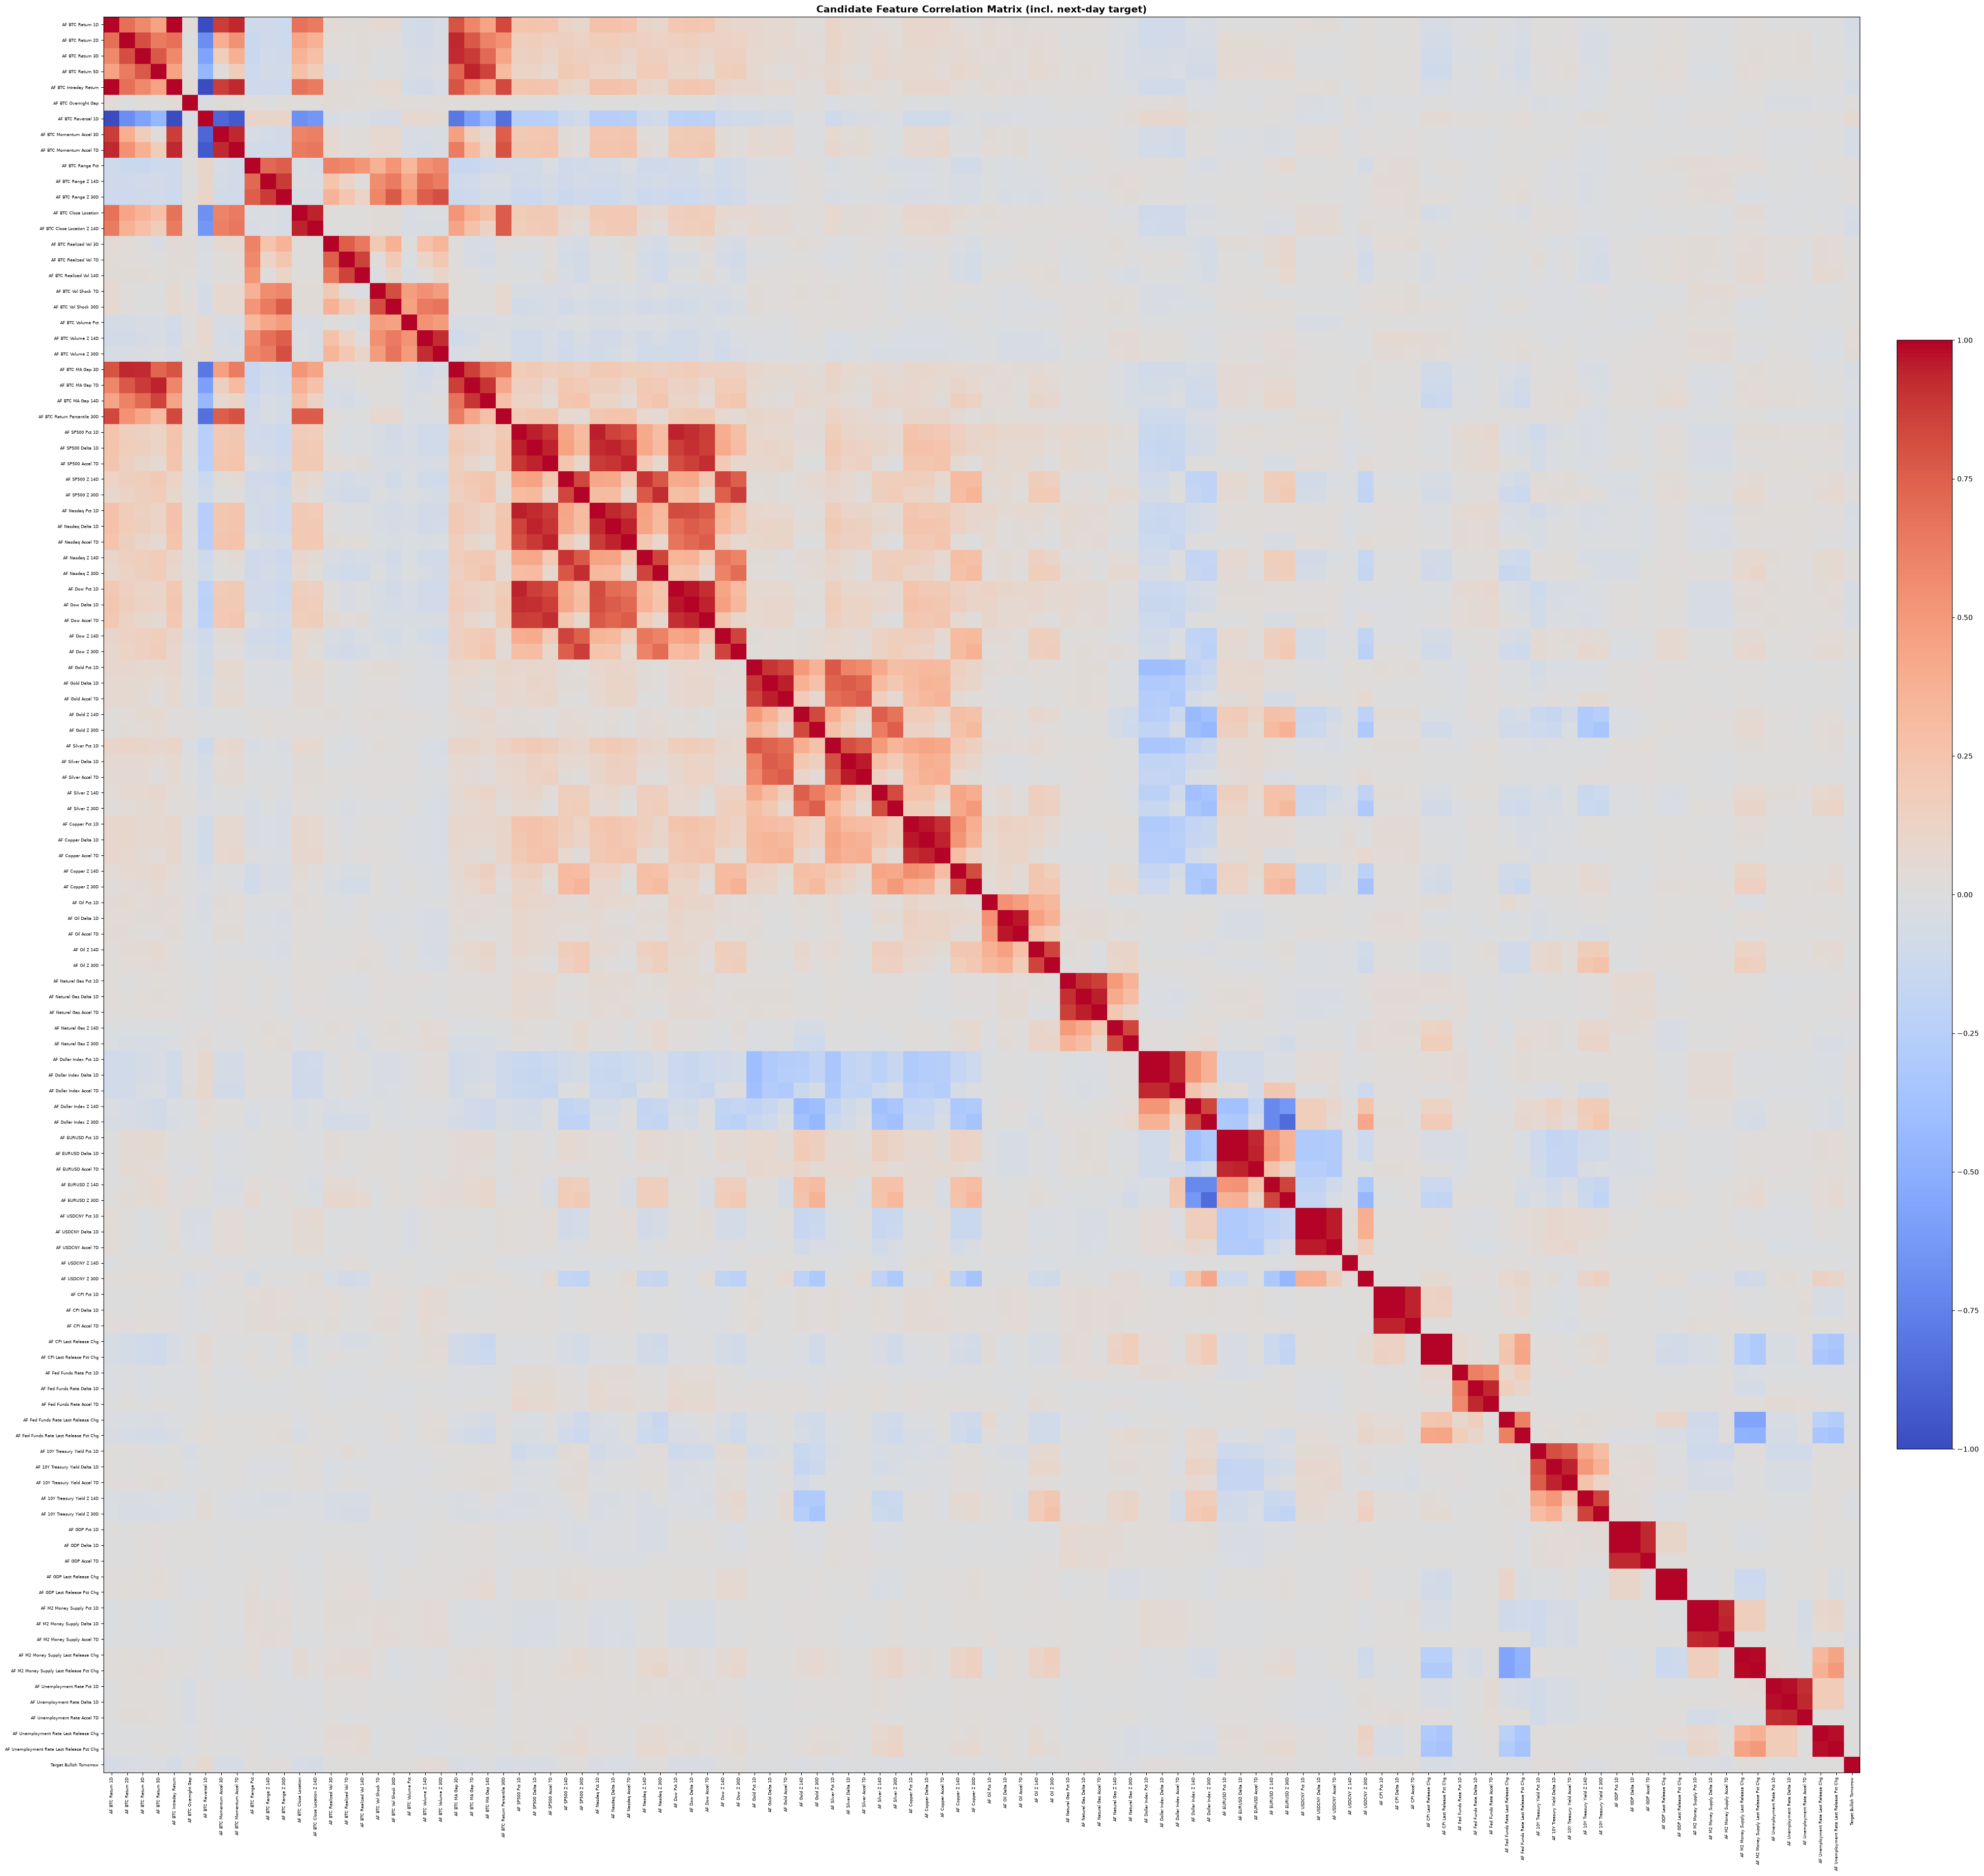

In [13]:
fig, ax = plt.subplots(figsize=(max(14, len(correlation_columns) * 0.35), max(12, len(correlation_columns) * 0.35)))
im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=90, fontsize=6)
ax.set_yticklabels(correlation_columns, fontsize=6)

fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
ax.set_title("Candidate Feature Correlation Matrix (incl. next-day target)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


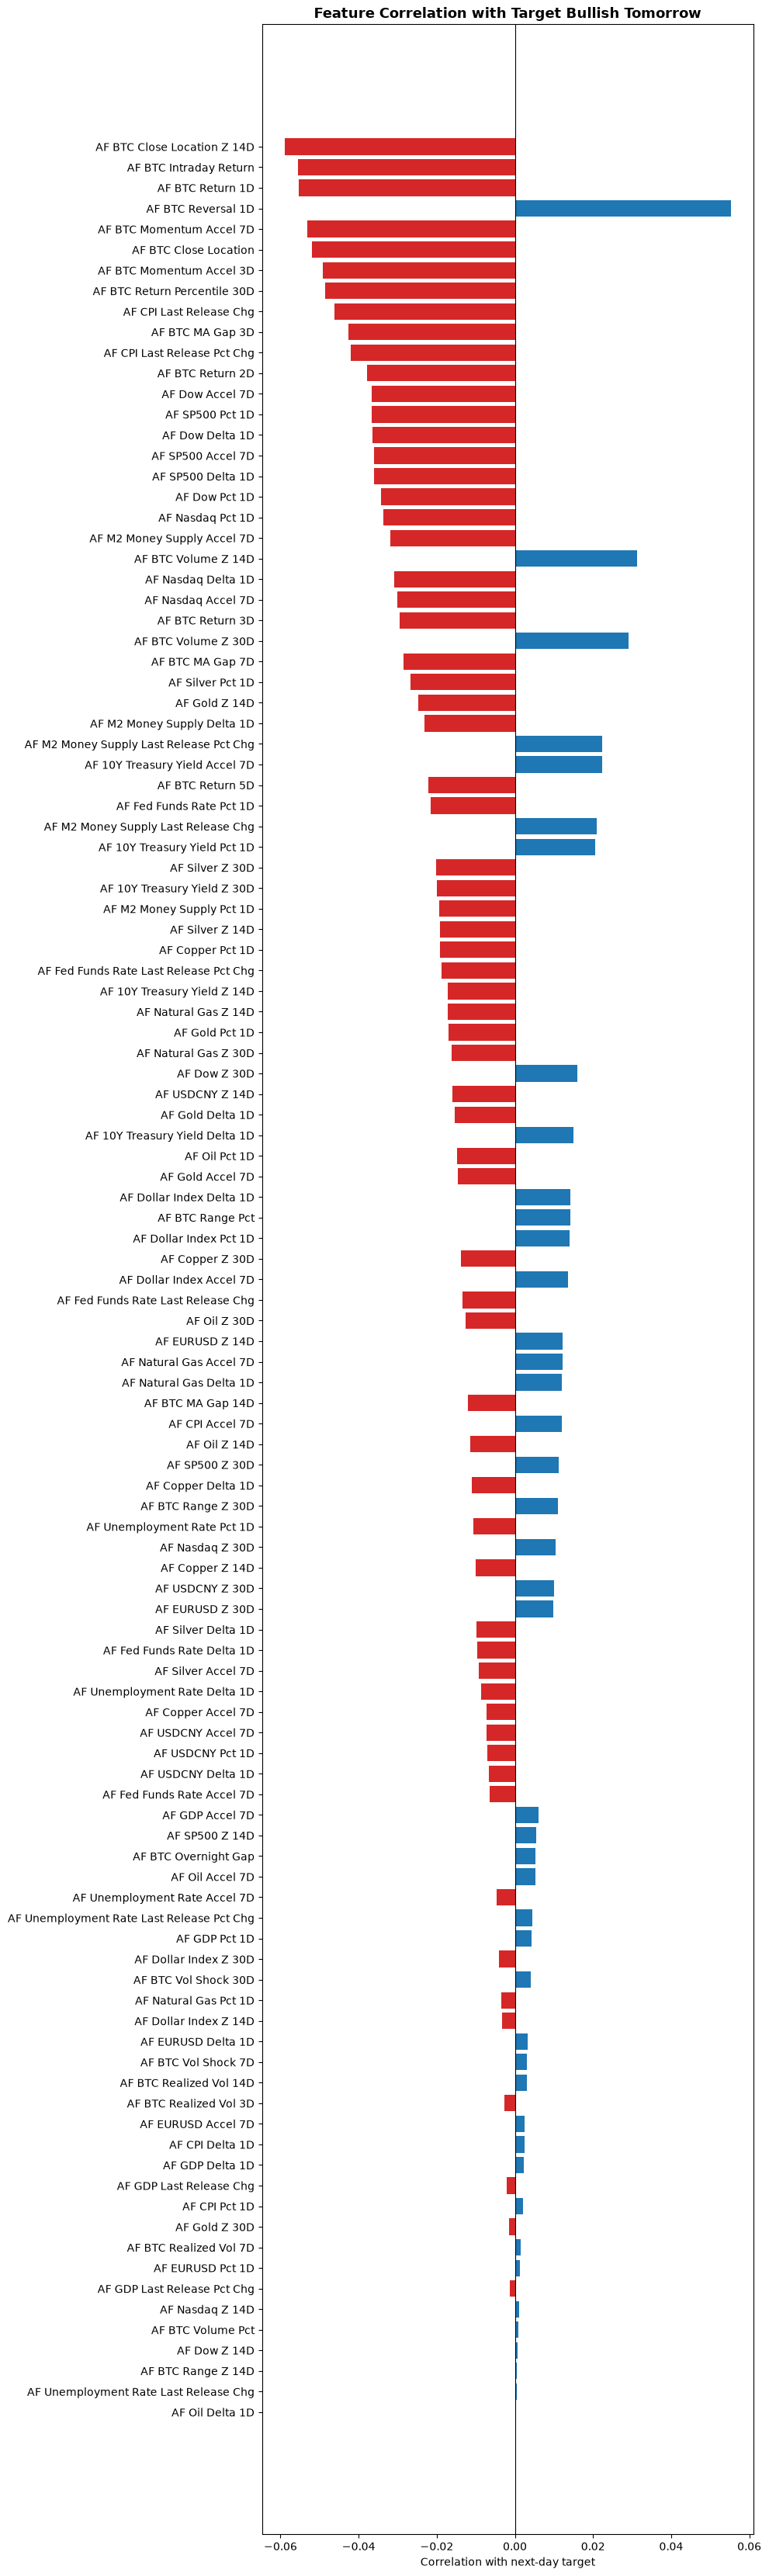

In [14]:
fig, ax = plt.subplots(figsize=(10, max(6, len(target_correlations) * 0.3)))
colors = ["#d62728" if v < 0 else "#1f77b4" for v in target_correlations.values]
ax.barh(target_correlations.index[::-1], target_correlations.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with next-day target")
ax.set_title("Feature Correlation with Target Bullish Tomorrow", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 12. Chronological Train/Test Split

Every row's features are built only from data known through that row's `Date` (all rolling/z-score calculations are trailing and shifted), and the target is next-day direction (`Close` on `Date + 1` vs `Close` on `Date`). To keep evaluation honest, the split below is purely chronological: the test period is entirely after the training period, so no test-period information can leak backward into feature selection, scaling, or model fitting.


In [15]:
MODEL_FRAME_CACHE = MK2_DATA_DIR / "fixed_feature_model_frame.csv"

model_frame = candidate_feature_table[["Date", "Target Bullish Tomorrow"] + candidate_feature_columns].copy()
# Drop the final row: its target (tomorrow's direction) is not yet knowable.
model_frame = model_frame.iloc[:-1]
model_frame = model_frame.replace([np.inf, -np.inf], np.nan)
# Intentionally not a blanket dropna() across all candidate columns: some quarterly/
# monthly macro series are flat between releases once forward-filled, which makes a
# handful of their rolling z-scores legitimately NaN (zero variance in that window).
# A blanket dropna would let one sparse column wipe out every row for every other
# feature. Only require the target itself to be present here; NaN-handling for
# whichever features actually get selected happens later, scoped to just those columns.
model_frame = model_frame.dropna(subset=["Target Bullish Tomorrow"])
model_frame = model_frame.sort_values("Date").reset_index(drop=True)
model_frame.to_csv(MODEL_FRAME_CACHE, index=False)

TEST_FRACTION = 0.2
split_idx = int(len(model_frame) * (1 - TEST_FRACTION))

train_frame = model_frame.iloc[:split_idx].reset_index(drop=True)
test_frame = model_frame.iloc[split_idx:].reset_index(drop=True)

assert train_frame["Date"].max() < test_frame["Date"].min(), "Train/test split is not chronological"

print(f"Train: {len(train_frame):,} rows, {train_frame['Date'].min()} to {train_frame['Date'].max()}")
print(f"Test:  {len(test_frame):,} rows, {test_frame['Date'].min()} to {test_frame['Date'].max()}")


Train: 2,921 rows, 2016-07-06 to 2024-07-04
Test:  731 rows, 2024-07-05 to 2026-07-05


## 13. Select a Fixed Feature Set (Training Data Only)

Features are ranked by correlation with the target, computed **only on the training window** — the test period is never touched here. To avoid picking up noise (the failure mode that hurt the daily-adaptive approach), a candidate also has to show the **same correlation sign in both halves of the training period** before it's eligible. This favors features with a persistent relationship over the training history over ones that just happen to score high overall.


In [16]:
def select_stable_features(train_df, feature_cols, target_col="Target Bullish Tomorrow", top_n=15, min_abs_corr=0.02, max_pairwise_corr=0.9):
    half = len(train_df) // 2
    first_half = train_df.iloc[:half]
    second_half = train_df.iloc[half:]

    y_full = train_df[target_col].astype(float)
    rows = []
    for feature in feature_cols:
        x_full = train_df[feature].astype(float)
        if x_full.nunique(dropna=True) <= 1:
            continue
        corr_full = x_full.corr(y_full)
        if pd.isna(corr_full):
            continue

        corr_first = first_half[feature].astype(float).corr(first_half[target_col].astype(float))
        corr_second = second_half[feature].astype(float).corr(second_half[target_col].astype(float))
        stable_sign = (
            pd.notna(corr_first) and pd.notna(corr_second)
            and np.sign(corr_first) == np.sign(corr_second) == np.sign(corr_full)
        )

        rows.append({
            "feature": feature,
            "corr_full_train": corr_full,
            "abs_corr_full_train": abs(corr_full),
            "corr_first_half": corr_first,
            "corr_second_half": corr_second,
            "stable_sign": stable_sign,
        })

    scores = pd.DataFrame(rows).sort_values("abs_corr_full_train", ascending=False).reset_index(drop=True)

    stable_candidates = scores[(scores["abs_corr_full_train"] >= min_abs_corr) & scores["stable_sign"]]
    top_candidates = stable_candidates["feature"].head(top_n).tolist()

    if not top_candidates:
        # Fallback so the pipeline can still run; flags that nothing cleared the stability bar.
        print("WARNING: no features passed the stability check, falling back to raw top correlations.")
        top_candidates = scores["feature"].head(top_n).tolist()

    # De-dup only within the original top_n candidates -- drop a feature if it's too
    # correlated with one already kept, but do NOT backfill from further down the
    # ranked list. This can leave fewer than top_n features selected; that's expected.
    selected = []
    for feature in top_candidates:
        x = train_df[feature].astype(float)
        too_similar = any(
            abs(x.corr(train_df[other].astype(float))) >= max_pairwise_corr
            for other in selected
        )
        if not too_similar:
            selected.append(feature)

    return selected, scores


SELECTED_FEATURES_CACHE = MK2_DATA_DIR / "fixed_selected_features.csv"
FEATURE_SELECTION_SCORES_CACHE = MK2_DATA_DIR / "feature_selection_scores.csv"

selected_features, selection_scores = select_stable_features(
    train_frame,
    candidate_feature_columns,
    top_n=15,
    min_abs_corr=0.02,
)

selection_scores.to_csv(FEATURE_SELECTION_SCORES_CACHE, index=False)
pd.Series(selected_features, name="feature").to_csv(SELECTED_FEATURES_CACHE, index=False)

print(f"Selected {len(selected_features)} features (train-only correlation, sign-stable across both training halves):")
for feature in selected_features:
    row = selection_scores.loc[selection_scores["feature"] == feature].iloc[0]
    print(f"  {feature:40s} corr={row['corr_full_train']:+.4f}")

Selected 9 features (train-only correlation, sign-stable across both training halves):
  AF BTC Close Location Z 14D              corr=-0.0726
  AF BTC Return Percentile 30D             corr=-0.0660
  AF BTC Intraday Return                   corr=-0.0649
  AF BTC Momentum Accel 3D                 corr=-0.0568
  AF BTC MA Gap 3D                         corr=-0.0510
  AF CPI Last Release Chg                  corr=-0.0459
  AF BTC Volume Z 14D                      corr=+0.0397
  AF M2 Money Supply Accel 7D              corr=-0.0365
  AF BTC MA Gap 7D                         corr=-0.0361


## 14. Fit Logistic Regression on the Selected Features

The scaler and model are both fit on `train_frame` only. `test_frame` is transformed with the already-fitted scaler and scored with the already-fitted model — it plays no role in choosing features, scaling parameters, or model weights.


In [17]:
# Drop NaNs scoped to just the selected features (not the full 111-column candidate
# pool), so a sparse macro column doesn't cost rows that every other feature needed.
train_eval = train_frame[["Date", "Target Bullish Tomorrow"] + selected_features].dropna().reset_index(drop=True)
test_eval = test_frame[["Date", "Target Bullish Tomorrow"] + selected_features].dropna().reset_index(drop=True)

print(f"Train rows usable by selected features: {len(train_eval):,} (of {len(train_frame):,})")
print(f"Test rows usable by selected features:  {len(test_eval):,} (of {len(test_frame):,})")

scaler = StandardScaler()
X_train = scaler.fit_transform(train_eval[selected_features])
y_train = train_eval["Target Bullish Tomorrow"].astype(int)

X_test = scaler.transform(test_eval[selected_features])
y_test = test_eval["Target Bullish Tomorrow"].astype(int)

fixed_feature_model = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000, random_state=42)
fixed_feature_model.fit(X_train, y_train)

print("Logistic regression equation:")
print("P(BTC bullish tomorrow) = 1 / (1 + e^(-z))")
print(f"z = {fixed_feature_model.intercept_[0]:.6f}")
for feature, coef in zip(selected_features, fixed_feature_model.coef_[0]):
    sign = "+" if coef >= 0 else "-"
    print(f"    {sign} {abs(coef):.6f} x {feature}")


Train rows usable by selected features: 2,849 (of 2,921)
Test rows usable by selected features:  731 (of 731)
Logistic regression equation:
P(BTC bullish tomorrow) = 1 / (1 + e^(-z))
z = 0.104359
    - 0.117883 x AF BTC Close Location Z 14D
    + 0.013824 x AF BTC Return Percentile 30D
    - 0.031748 x AF BTC Intraday Return
    - 0.015421 x AF BTC Momentum Accel 3D
    - 0.006185 x AF BTC MA Gap 3D
    - 0.099778 x AF CPI Last Release Chg
    + 0.072985 x AF BTC Volume Z 14D
    - 0.091106 x AF M2 Money Supply Accel 7D
    - 0.031355 x AF BTC MA Gap 7D


## 15. Evaluate on the Held-Out Test Period

The test period is entirely after the training period (enforced above), so this is a genuine out-of-sample, walk-forward-style check rather than an in-sample fit.


In [18]:
test_pred = fixed_feature_model.predict(X_test)
test_proba = fixed_feature_model.predict_proba(X_test)[:, 1]
train_pred = fixed_feature_model.predict(X_train)

majority_baseline = max(y_test.mean(), 1 - y_test.mean())

evaluation_summary = pd.DataFrame([{
    "train_start": train_eval["Date"].min(),
    "train_end": train_eval["Date"].max(),
    "test_start": test_eval["Date"].min(),
    "test_end": test_eval["Date"].max(),
    "train_samples": len(train_eval),
    "test_samples": len(test_eval),
    "num_features": len(selected_features),
    "train_accuracy": accuracy_score(y_train, train_pred),
    "test_accuracy": accuracy_score(y_test, test_pred),
    "test_f1": f1_score(y_test, test_pred),
    "test_precision": precision_score(y_test, test_pred),
    "test_recall": recall_score(y_test, test_pred),
    "test_roc_auc": roc_auc_score(y_test, test_proba),
    "majority_baseline": majority_baseline,
    "beat_baseline_by": accuracy_score(y_test, test_pred) - majority_baseline,
}])

EVALUATION_SUMMARY_CACHE = MK2_DATA_DIR / "fixed_feature_logistic_evaluation.csv"
evaluation_summary.to_csv(EVALUATION_SUMMARY_CACHE, index=False)

print("Confusion matrix (test period):")
print(confusion_matrix(y_test, test_pred))
evaluation_summary


Confusion matrix (test period):
[[121 245]
 [106 259]]


,train_start,train_end,test_start,test_end,train_samples,test_samples,num_features,train_accuracy,test_accuracy,test_f1,test_precision,test_recall,test_roc_auc,majority_baseline,beat_baseline_by
0,2016-09-16,2024-07-04,2024-07-05,2026-07-05,2849,731,9,0.542647,0.519836,0.596087,0.513889,0.709589,0.512501,0.500684,0.019152


## 16. Full-History Walk-Forward Backtest (2016-07-06 to 2026-07-06)

The single 80/20 split above only tests the most recent ~2 years. To get an honest read across the full 10-year history, this walks an **expanding training window** forward in 1-year folds: fold *k* trains on everything before its test year and predicts only that year, so every prediction is still strictly out-of-sample. Feature selection (`select_stable_features`) and the logistic regression are both refit from scratch each fold, train-only, exactly as in the single-split version above -- nothing from a fold's test year ever touches that fold's training data.

The first 2 years (2016-07-06 to 2018-07-06) are used only as the initial training window and are never scored -- there is no way to test on data before any training data exists. Every day from 2018-07-06 through 2026-07-05 is scored exactly once, as an out-of-sample prediction.

In [19]:
WALK_FORWARD_CACHE = MK2_DATA_DIR / "walk_forward_full_history.csv"

INITIAL_TRAIN_YEARS = 2
FOLD_LENGTH_DAYS = 365

wf_frame = model_frame.copy()
wf_frame["Date"] = pd.to_datetime(wf_frame["Date"])
history_start = wf_frame["Date"].min()
history_end = wf_frame["Date"].max()

fold_results = []
all_actuals = []
all_preds = []

fold_start = history_start + pd.DateOffset(years=INITIAL_TRAIN_YEARS)
fold_num = 0

while fold_start <= history_end:
    fold_end = min(fold_start + pd.Timedelta(days=FOLD_LENGTH_DAYS), history_end + pd.Timedelta(days=1))
    fold_num += 1

    train_fold = wf_frame[wf_frame["Date"] < fold_start]
    test_fold = wf_frame[(wf_frame["Date"] >= fold_start) & (wf_frame["Date"] < fold_end)]

    if len(test_fold) == 0:
        break

    # Train-only feature selection, refit each fold -- the test year never
    # influences which features are chosen, same rule as the single-split version.
    fold_selected, _ = select_stable_features(
        train_fold, candidate_feature_columns, top_n=15, min_abs_corr=0.02,
    )

    train_fold_eval = train_fold.dropna(subset=fold_selected + ["Target Bullish Tomorrow"])
    test_fold_eval = test_fold.dropna(subset=fold_selected + ["Target Bullish Tomorrow"])

    if len(train_fold_eval) >= 30 and len(test_fold_eval) > 0:
        X_train_fold = train_fold_eval[fold_selected]
        y_train_fold = train_fold_eval["Target Bullish Tomorrow"].astype(int)
        X_test_fold = test_fold_eval[fold_selected]
        y_test_fold = test_fold_eval["Target Bullish Tomorrow"].astype(int)

        fold_scaler = StandardScaler().fit(X_train_fold)
        X_train_scaled = fold_scaler.transform(X_train_fold)
        X_test_scaled = fold_scaler.transform(X_test_fold)

        fold_model = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train_fold)
        fold_pred = fold_model.predict(X_test_scaled)

        fold_majority = max(y_test_fold.mean(), 1 - y_test_fold.mean())
        fold_accuracy = accuracy_score(y_test_fold, fold_pred)

        fold_results.append({
            "fold": fold_num,
            "train_start": train_fold_eval["Date"].min().date(),
            "train_end": train_fold_eval["Date"].max().date(),
            "test_start": test_fold_eval["Date"].min().date(),
            "test_end": test_fold_eval["Date"].max().date(),
            "train_samples": len(train_fold_eval),
            "test_samples": len(test_fold_eval),
            "num_features": len(fold_selected),
            "accuracy": fold_accuracy,
            "majority_baseline": fold_majority,
            "beat_baseline_by": fold_accuracy - fold_majority,
        })

        all_actuals.extend(y_test_fold.tolist())
        all_preds.extend(fold_pred.tolist())

    fold_start = fold_end

walk_forward_results = pd.DataFrame(fold_results)
walk_forward_results.to_csv(WALK_FORWARD_CACHE, index=False)

overall_accuracy = accuracy_score(all_actuals, all_preds)
overall_up_rate = float(np.mean(all_actuals))
overall_majority = max(overall_up_rate, 1 - overall_up_rate)

print(f"Walk-forward folds: {len(walk_forward_results)}")
print(f"Pooled out-of-sample predictions: {len(all_actuals)}")
coverage_start = walk_forward_results["test_start"].min()
coverage_end = walk_forward_results["test_end"].max()
print(f"Coverage: {coverage_start} to {coverage_end}")
print(f"Pooled walk-forward accuracy: {overall_accuracy:.4f}")
print(f"Pooled actual up-rate: {overall_up_rate:.4f}")
print(f"Pooled majority baseline: {overall_majority:.4f}")
print(f"Beats pooled baseline by: {overall_accuracy - overall_majority:+.4f}")
walk_forward_results


Walk-forward folds: 9
Pooled out-of-sample predictions: 2922
Coverage: 2018-07-06 to 2026-07-05
Pooled walk-forward accuracy: 0.5294
Pooled actual up-rate: 0.5086
Pooled majority baseline: 0.5086
Beats pooled baseline by: +0.0209


,fold,train_start,train_end,test_start,test_end,train_samples,test_samples,num_features,accuracy,majority_baseline,beat_baseline_by
0,1,2016-10-07,2018-07-05,2018-07-06,2019-07-05,637,365,11,0.558904,0.542466,0.016438
1,2,2017-01-27,2019-07-05,2019-07-06,2020-07-04,890,365,12,0.487671,0.509589,-0.021918
2,3,2016-08-06,2020-07-04,2020-07-05,2021-07-04,1429,365,6,0.567123,0.558904,0.008219
3,4,2016-08-06,2021-07-04,2021-07-05,2022-07-04,1794,365,7,0.509589,0.501370,0.008219
4,5,2016-09-16,2022-07-04,2022-07-05,2023-07-04,2118,365,9,0.517808,0.531507,-0.013699
5,6,2016-09-16,2023-07-04,2023-07-05,2024-07-03,2483,365,8,0.547945,0.512329,0.035616
6,7,2016-09-16,2024-07-03,2024-07-04,2025-07-03,2848,365,9,0.572603,0.515068,0.057534
7,8,2016-09-16,2025-07-03,2025-07-04,2026-07-03,3213,365,8,0.476712,0.520548,-0.043836
8,9,2016-09-16,2026-07-03,2026-07-04,2026-07-05,3578,2,8,0.000000,1.000000,-1.000000


## 17. Original-Model Feature Replication (Supervised-Learning-BTC-Price-Direction)

The earlier `Supervised-Learning-BTC-Price-Direction/Pricing Models/ML-MODELS.ipynb` project settled on a small, deliberately-chosen 14-feature set rather than searching a large candidate pool:

- **On-chain (4):** `Miner Reserve` (7d diff), `Hashrate` (7d rolling mean), `Mean Coin Age` (7d pct change), `Open Interest` (1d pct change)
- **Market (6):** 1-day pct change of S&P500, Nasdaq, Dow, Gold, Silver, Copper
- **Economic (4):** Fed Funds level, Fed Funds 1d delta, 10Y Treasury 1d pct change, 10Y Treasury 5d delta

Market and economic series already exist in `raw_model_table` (market via yfinance, economic via the leakage-safe FRED pull from Section 8), so those 10 features are rebuilt directly from mk4's own, already-fixed data. On-chain data is not reproducible live here (Section 6's CryptoQuant plan-history limitation), so the 4 on-chain features are rebuilt from that project's static `on-chain-data.csv` export, cached as `legacy_onchain_data.csv` -- real historical CryptoQuant pulls, just not live and not spanning the full 10 years.

This is used as a **fixed** feature set, not a candidate pool to search -- consistent with what Section 16's experiments showed about correlation-search overfitting the larger pool.

In [20]:
LEGACY_ONCHAIN_CACHE = MK2_DATA_DIR / "legacy_onchain_data.csv"

legacy_onchain = pd.read_csv(LEGACY_ONCHAIN_CACHE)
legacy_onchain["Date"] = pd.to_datetime(legacy_onchain["Datetime"], utc=True).dt.tz_localize(None).dt.date
legacy_onchain = legacy_onchain.sort_values("Date").drop_duplicates(subset=["Date"]).reset_index(drop=True)

print(f"Legacy on-chain data: {legacy_onchain['Date'].min()} to {legacy_onchain['Date'].max()} ({len(legacy_onchain):,} rows)")
print("NOTE: this does not cover the full 2016-2026 window -- rows outside this range will have NaN on-chain features below.")

orig_frame = raw_model_table[["Date", "Target Bullish Tomorrow", "SP500", "Nasdaq", "Dow", "Gold", "Silver", "Copper",
                               "Fed Funds Rate", "10Y Treasury Yield"]].copy()
orig_frame = orig_frame.sort_values("Date").reset_index(drop=True)
orig_frame = pd.merge(orig_frame, legacy_onchain[["Date", "Miner Reserve", "Hashrate", "Mean Coin Age", "Open Interest"]],
                       on="Date", how="left")

# On-chain transforms, matching the original notebook exactly.
orig_frame["Tr Miner Reserve 1"] = orig_frame["Miner Reserve"] - orig_frame["Miner Reserve"].shift(7)
orig_frame["Tr Hashrate 1"] = orig_frame["Hashrate"].rolling(7).mean()
orig_frame["Tr Mean Coin Age 2"] = orig_frame["Mean Coin Age"].pct_change(7)
orig_frame["Tr Open Interest"] = orig_frame["Open Interest"].pct_change()

# Market transforms, from mk4's own yfinance pull (Section 7).
orig_frame["Tr S&P500"] = orig_frame["SP500"].pct_change()
orig_frame["Tr Nasdaq"] = orig_frame["Nasdaq"].pct_change()
orig_frame["Tr Dow"] = orig_frame["Dow"].pct_change()
orig_frame["Tr Gold"] = orig_frame["Gold"].pct_change()
orig_frame["Tr Silver"] = orig_frame["Silver"].pct_change()
orig_frame["Tr Copper"] = orig_frame["Copper"].pct_change()

# Economic transforms, from mk4's own leakage-safe FRED pull (Section 8).
orig_frame["Tr Fed Funds Raw"] = orig_frame["Fed Funds Rate"]
orig_frame["Tr Fed Funds Delta"] = orig_frame["Fed Funds Rate"] - orig_frame["Fed Funds Rate"].shift(1)
orig_frame["Tr Treasury Pct"] = orig_frame["10Y Treasury Yield"].pct_change()
orig_frame["Tr Treasury Delta"] = orig_frame["10Y Treasury Yield"] - orig_frame["10Y Treasury Yield"].shift(5)

ORIGINAL_MODEL_FEATURES = [
    "Tr Miner Reserve 1", "Tr Hashrate 1", "Tr Mean Coin Age 2", "Tr Open Interest",
    "Tr S&P500", "Tr Nasdaq", "Tr Dow", "Tr Gold", "Tr Silver", "Tr Copper",
    "Tr Fed Funds Raw", "Tr Fed Funds Delta", "Tr Treasury Pct", "Tr Treasury Delta",
]

orig_frame = orig_frame[["Date", "Target Bullish Tomorrow"] + ORIGINAL_MODEL_FEATURES]
orig_frame = orig_frame.replace([np.inf, -np.inf], np.nan)
orig_frame = orig_frame.dropna(subset=["Target Bullish Tomorrow"]).sort_values("Date").reset_index(drop=True)

ORIGINAL_MODEL_FRAME_CACHE = MK2_DATA_DIR / "original_model_frame.csv"
orig_frame.to_csv(ORIGINAL_MODEL_FRAME_CACHE, index=False)

fully_usable = orig_frame.dropna(subset=ORIGINAL_MODEL_FEATURES)
print(f"\nFull frame: {len(orig_frame):,} rows, {orig_frame['Date'].min()} to {orig_frame['Date'].max()}")
print(f"Rows with all 14 features present (usable): {len(fully_usable):,}, {fully_usable['Date'].min()} to {fully_usable['Date'].max()}")
orig_frame.tail()


Legacy on-chain data: 2019-03-30 to 2025-06-09 (2,264 rows)
NOTE: this does not cover the full 2016-2026 window -- rows outside this range will have NaN on-chain features below.

Full frame: 3,653 rows, 2016-07-06 to 2026-07-06
Rows with all 14 features present (usable): 2,257, 2019-04-06 to 2025-06-09


,Date,Target Bullish Tomorrow,Tr Miner Reserve 1,Tr Hashrate 1,Tr Mean Coin Age 2,Tr Open Interest,Tr S&P500,Tr Nasdaq,Tr Dow,Tr Gold,Tr Silver,Tr Copper,Tr Fed Funds Raw,Tr Fed Funds Delta,Tr Treasury Pct,Tr Treasury Delta
3648,2026-07-02,1,NaN,NaN,NaN,NaN,0.000001,-0.007963,0.011372,0.010914,0.009287,-0.001470,3.63,0.0,0.009009,0.10
3649,2026-07-03,1,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.63,0.0,0.002232,0.11
3650,2026-07-04,1,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.63,0.0,0.000000,0.11
3651,2026-07-05,1,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.63,0.0,0.000000,0.11
3652,2026-07-06,0,NaN,NaN,NaN,NaN,0.008490,0.012246,0.002015,0.015489,0.032766,0.023305,3.63,0.0,0.000000,0.05


### 17a. Evaluate the Original-Model Feature Set

Same two evaluations as before (single chronological 80/20 split, and full walk-forward with an expanding window), but using only the 14 fixed features above -- no correlation search, no re-selection per fold. Restricted to the window where on-chain data actually exists (2019-04-06 to 2025-06-09); rows outside that range are dropped since the on-chain features are NaN there.

In [21]:
orig_usable = orig_frame.dropna(subset=ORIGINAL_MODEL_FEATURES).sort_values("Date").reset_index(drop=True)

# --- Single chronological 80/20 split ---
split_idx = int(len(orig_usable) * 0.8)
orig_train = orig_usable.iloc[:split_idx].reset_index(drop=True)
orig_test = orig_usable.iloc[split_idx:].reset_index(drop=True)
assert orig_train["Date"].max() < orig_test["Date"].min()

Xtr = orig_train[ORIGINAL_MODEL_FEATURES]
ytr = orig_train["Target Bullish Tomorrow"].astype(int)
Xte = orig_test[ORIGINAL_MODEL_FEATURES]
yte = orig_test["Target Bullish Tomorrow"].astype(int)

orig_scaler = StandardScaler().fit(Xtr)
orig_model = LogisticRegression(max_iter=1000).fit(orig_scaler.transform(Xtr), ytr)
orig_pred = orig_model.predict(orig_scaler.transform(Xte))

orig_acc = accuracy_score(yte, orig_pred)
orig_baseline = max(ytr.mean() >= 0.5 and ytr.mean() or 1 - ytr.mean(), 0)
orig_baseline = max(yte.mean(), 1 - yte.mean())

print("=== Single 80/20 split, original-model 14-feature set ===")
print(f"Train: {len(orig_train):,} rows, {orig_train['Date'].min()} to {orig_train['Date'].max()}")
print(f"Test:  {len(orig_test):,} rows, {orig_test['Date'].min()} to {orig_test['Date'].max()}")
print(f"Accuracy: {orig_acc:.4f}   Baseline: {orig_baseline:.4f}   Edge: {orig_acc - orig_baseline:+.4f}")
print(confusion_matrix(yte, orig_pred))


=== Single 80/20 split, original-model 14-feature set ===
Train: 1,805 rows, 2019-04-06 to 2024-03-14
Test:  452 rows, 2024-03-15 to 2025-06-09
Accuracy: 0.5487   Baseline: 0.5044   Edge: +0.0442
[[ 73 151]
 [ 53 175]]


### 17b. Full Walk-Forward, Original-Model Feature Set

In [22]:
from scipy.stats import binomtest

orig_history_start = orig_usable["Date"].min()
orig_history_start = pd.Timestamp(orig_history_start)
orig_history_end = pd.Timestamp(orig_usable["Date"].max())

orig_fold_start = orig_history_start + pd.DateOffset(years=1)
orig_fold_results = []
orig_all_actual, orig_all_pred, orig_all_base = [], [], []
orig_fold_num = 0

orig_usable_ts = orig_usable.copy()
orig_usable_ts["Date"] = pd.to_datetime(orig_usable_ts["Date"])

while orig_fold_start <= orig_history_end:
    fold_end = min(orig_fold_start + pd.Timedelta(days=365), orig_history_end + pd.Timedelta(days=1))
    orig_fold_num += 1

    train_fold = orig_usable_ts[orig_usable_ts["Date"] < orig_fold_start]
    test_fold = orig_usable_ts[(orig_usable_ts["Date"] >= orig_fold_start) & (orig_usable_ts["Date"] < fold_end)]

    if len(test_fold) == 0:
        break

    if len(train_fold) >= 30:
        Xtr_f = train_fold[ORIGINAL_MODEL_FEATURES]
        ytr_f = train_fold["Target Bullish Tomorrow"].astype(int)
        Xte_f = test_fold[ORIGINAL_MODEL_FEATURES]
        yte_f = test_fold["Target Bullish Tomorrow"].astype(int)

        sc_f = StandardScaler().fit(Xtr_f)
        m_f = LogisticRegression(max_iter=1000).fit(sc_f.transform(Xtr_f), ytr_f)
        pred_f = m_f.predict(sc_f.transform(Xte_f))

        majority_class = int(ytr_f.mean() >= 0.5)
        base_pred = np.full(len(yte_f), majority_class)

        fold_acc = accuracy_score(yte_f, pred_f)
        fold_base = accuracy_score(yte_f, base_pred)

        orig_fold_results.append({
            "fold": orig_fold_num,
            "train_samples": len(train_fold),
            "test_start": test_fold["Date"].min().date(),
            "test_end": test_fold["Date"].max().date(),
            "test_samples": len(test_fold),
            "accuracy": fold_acc,
            "majority_baseline": fold_base,
            "beat_baseline_by": fold_acc - fold_base,
        })

        orig_all_actual.extend(yte_f.tolist())
        orig_all_pred.extend(pred_f.tolist())
        orig_all_base.extend(base_pred.tolist())

    orig_fold_start = fold_end

orig_all_actual = np.array(orig_all_actual)
orig_all_pred = np.array(orig_all_pred)
orig_all_base = np.array(orig_all_base)

pooled_acc = accuracy_score(orig_all_actual, orig_all_pred)
pooled_base = accuracy_score(orig_all_actual, orig_all_base)
model_correct = (orig_all_pred == orig_all_actual)
base_correct = (orig_all_base == orig_all_actual)
b = np.sum(model_correct & ~base_correct)
c = np.sum(~model_correct & base_correct)
p_value = binomtest(b, b + c, 0.5).pvalue if (b + c) > 0 else float("nan")

print("=== Full walk-forward, original-model 14-feature set ===")
print(f"Folds: {len(orig_fold_results)}   Pooled predictions: {len(orig_all_actual)}")
print(f"Pooled accuracy: {pooled_acc:.4f}   Pooled baseline: {pooled_base:.4f}   Edge: {pooled_acc - pooled_base:+.4f}")
print(f"McNemar b={b} c={c}  p-value={p_value:.4f}")
print()
ORIGINAL_MODEL_WALK_FORWARD_CACHE = MK2_DATA_DIR / "original_model_walk_forward.csv"
orig_wf_df = pd.DataFrame(orig_fold_results)
orig_wf_df.to_csv(ORIGINAL_MODEL_WALK_FORWARD_CACHE, index=False)
orig_wf_df


=== Full walk-forward, original-model 14-feature set ===
Folds: 6   Pooled predictions: 1891
Pooled accuracy: 0.5394   Pooled baseline: 0.5124   Edge: +0.0270
McNemar b=600 c=549  p-value=0.1402



,fold,train_samples,test_start,test_end,test_samples,accuracy,majority_baseline,beat_baseline_by
0,1,366,2020-04-06,2021-04-05,365,0.556164,0.580822,-0.024658
1,2,731,2021-04-06,2022-04-05,365,0.542466,0.504110,0.038356
2,3,1096,2022-04-06,2023-04-05,365,0.564384,0.452055,0.112329
3,4,1461,2023-04-06,2024-04-04,365,0.482192,0.520548,-0.038356
4,5,1826,2024-04-05,2025-04-04,365,0.553425,0.493151,0.060274
5,6,2191,2025-04-05,2025-06-09,66,0.530303,0.575758,-0.045455


### 17c. Original-Model Market + Economic Features Only, Full 8-Year Backtest

The on-chain features can't cover the full 2018-2026 window (legacy export is 2019-03 to 2025-06 only), so this drops the 4 on-chain features and keeps just the 10 market + economic features -- all sourced from mk4's own full-history, leakage-safe pipeline. Same expanding-window walk-forward methodology as Section 16 (2-year initial training window, 1-year folds, no feature re-selection since this set is fixed), so it's directly comparable to the 111-candidate and curated-28 results from earlier.

In [23]:
MARKET_ECON_FEATURES = [
    "Tr S&P500", "Tr Nasdaq", "Tr Dow", "Tr Gold", "Tr Silver", "Tr Copper",
    "Tr Fed Funds Raw", "Tr Fed Funds Delta", "Tr Treasury Pct", "Tr Treasury Delta",
]

me_frame = orig_frame[["Date", "Target Bullish Tomorrow"] + MARKET_ECON_FEATURES].copy()
me_frame = me_frame.dropna(subset=MARKET_ECON_FEATURES).sort_values("Date").reset_index(drop=True)
me_frame["Date"] = pd.to_datetime(me_frame["Date"])

print(f"Usable rows: {len(me_frame):,}, {me_frame['Date'].min().date()} to {me_frame['Date'].max().date()}")

me_history_start = me_frame["Date"].min()
me_history_end = me_frame["Date"].max()
me_fold_start = me_history_start + pd.DateOffset(years=2)

me_fold_results = []
me_all_actual, me_all_pred, me_all_base = [], [], []
me_fold_num = 0

while me_fold_start <= me_history_end:
    fold_end = min(me_fold_start + pd.Timedelta(days=365), me_history_end + pd.Timedelta(days=1))
    me_fold_num += 1

    train_fold = me_frame[me_frame["Date"] < me_fold_start]
    test_fold = me_frame[(me_frame["Date"] >= me_fold_start) & (me_frame["Date"] < fold_end)]

    if len(test_fold) == 0:
        break

    if len(train_fold) >= 30:
        Xtr_f = train_fold[MARKET_ECON_FEATURES]
        ytr_f = train_fold["Target Bullish Tomorrow"].astype(int)
        Xte_f = test_fold[MARKET_ECON_FEATURES]
        yte_f = test_fold["Target Bullish Tomorrow"].astype(int)

        sc_f = StandardScaler().fit(Xtr_f)
        m_f = LogisticRegression(max_iter=1000).fit(sc_f.transform(Xtr_f), ytr_f)
        pred_f = m_f.predict(sc_f.transform(Xte_f))

        majority_class = int(ytr_f.mean() >= 0.5)
        base_pred = np.full(len(yte_f), majority_class)

        fold_acc = accuracy_score(yte_f, pred_f)
        fold_base = accuracy_score(yte_f, base_pred)

        me_fold_results.append({
            "fold": me_fold_num,
            "train_samples": len(train_fold),
            "test_start": test_fold["Date"].min().date(),
            "test_end": test_fold["Date"].max().date(),
            "test_samples": len(test_fold),
            "accuracy": fold_acc,
            "majority_baseline": fold_base,
            "beat_baseline_by": fold_acc - fold_base,
        })

        me_all_actual.extend(yte_f.tolist())
        me_all_pred.extend(pred_f.tolist())
        me_all_base.extend(base_pred.tolist())

    me_fold_start = fold_end

me_all_actual = np.array(me_all_actual)
me_all_pred = np.array(me_all_pred)
me_all_base = np.array(me_all_base)

me_pooled_acc = accuracy_score(me_all_actual, me_all_pred)
me_pooled_base = accuracy_score(me_all_actual, me_all_base)
me_model_correct = (me_all_pred == me_all_actual)
me_base_correct = (me_all_base == me_all_actual)
b2 = np.sum(me_model_correct & ~me_base_correct)
c2 = np.sum(~me_model_correct & me_base_correct)
p2 = binomtest(b2, b2 + c2, 0.5).pvalue if (b2 + c2) > 0 else float("nan")

print("\n=== Full 8-year walk-forward, original-model market+economic features only (10) ===")
print(f"Folds: {len(me_fold_results)}   Pooled predictions: {len(me_all_actual)}")
print(f"Pooled accuracy: {me_pooled_acc:.4f}   Pooled baseline: {me_pooled_base:.4f}   Edge: {me_pooled_acc - me_pooled_base:+.4f}")
print(f"McNemar b={b2} c={c2}  p-value={p2:.4f}")
print()
MARKET_ECON_WALK_FORWARD_CACHE = MK2_DATA_DIR / "market_econ_walk_forward.csv"
me_wf_df = pd.DataFrame(me_fold_results)
me_wf_df.to_csv(MARKET_ECON_WALK_FORWARD_CACHE, index=False)
me_wf_df


Usable rows: 3,626, 2016-08-02 to 2026-07-06

=== Full 8-year walk-forward, original-model market+economic features only (10) ===
Folds: 8   Pooled predictions: 2896
Pooled accuracy: 0.5117   Pooled baseline: 0.5086   Edge: +0.0031
McNemar b=651 c=642  p-value=0.8240



,fold,train_samples,test_start,test_end,test_samples,accuracy,majority_baseline,beat_baseline_by
0,1,730,2018-08-02,2019-08-01,365,0.463014,0.545205,-0.082192
1,2,1095,2019-08-02,2020-07-31,365,0.506849,0.501370,0.005479
2,3,1460,2020-08-01,2021-07-31,365,0.556164,0.553425,0.002740
3,4,1825,2021-08-01,2022-07-31,365,0.509589,0.487671,0.021918
4,5,2190,2022-08-01,2023-07-31,365,0.528767,0.468493,0.060274
5,6,2555,2023-08-01,2024-07-30,365,0.490411,0.517808,-0.027397
6,7,2920,2024-07-31,2025-07-30,365,0.528767,0.515068,0.013699
7,8,3285,2025-07-31,2026-07-06,341,0.510264,0.478006,0.032258
